<div align="center">

<img src="https://javier.rodriguez.org.mx/itesm/2014/tecnologico-de-monterrey-blue.png" width="500"/>

<br>

*Tec de Monterrey Campus Santa Fe*

<br>

*Desarrollo de aplicaciones avanzadas de ciencias computacionales (Gpo 502)*

<br>

*SMS Classification: Ham vs Spam vs Smishing*

<br>

*Profesor*<br>
Ahmed Imad Hammoodi AL-Jarah

<br>

*Alumnos*<br>
Juan Pablo Ruiz de Chávez Diez de Urdanivia A01783127<br>
Marcos Dayan Mann A01782876<br>
Gabriel Edid Harari A01782146

<br>

*Fecha de entrega*<br>
04 de Junio del 2026

In this notebook, we build a model that classifies SMS messages into three classes:
- **ham**: normal legitimate message
- **spam**: unwanted promotional message
- **smishing**: phishing message sent by SMS

We kept the workflow focused on models and preprocessing steps that we can explain clearly in class. The three models we compare are:
1. **Complement Naive Bayes**
2. **Logistic Regression**
3. **Linear SVM**


## 1. Setup

We import the libraries, set a seed for reproducibility, and configure the plots.

In [1]:
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## 2. Reconciliation of the different datasets

Instead of using a single dataset we will build a working dataset from **three real, publicly available SMS datasets** that were downloaded from the internet:

1. **Mishra & Soni (2022)** — *SMS Phishing Dataset for Machine Learning and Pattern Recognition* (Mendeley, CC BY 4.0). It already contains the three classes (`ham`, `spam`, `smishing`) and is our main source. File: `data/raw/Dataset_5971_mishra_soni.csv`. URL: https://data.mendeley.com/datasets/f45bkkt8pr/1
2. **UCI SMS Spam Collection** — the classic benchmark with `ham` and `spam` messages. File: `data/raw/sms_spam_collection_uci.csv`. URL: https://archive.ics.uci.edu/dataset/228/sms+spam+collection
3. **Combined Smishing Dataset (Hosseinpour et al.)** — a large collection that consolidates several public sources, used here to reinforce the `smishing` and `spam` classes. File: `data/raw/combined_smishing_shaghayegh.csv`. URL: https://github.com/shaghayegh-hp/Smishing_Dataset

### Why a reconciliation step is needed
The three files do **not** share the same structure:

| Source | Label column(s) | Text column | Label format |
|---|---|---|---|
| Mishra & Soni | `LABEL` | `TEXT` | `ham` / `spam` / `Smishing` (mixed case) |
| UCI | `v1` | `v2` | `ham` / `spam` |
| Combined | `spam label`, `smishing label` | `message` | binary flags (`0`/`1`) |

To merge them we have to **harmonize the schema**, **normalize the labels**, **rebuild the `URL` / `EMAIL` / `PHONE` indicators consistently**, **remove duplicates**, and **keep the classes roughly even** so no single class dominates training.

### Reconciliation steps
1. Load each source and rename its columns to a common `LABEL` / `TEXT` schema.
2. Normalize every label to lowercase and map variants (`Smishing` → `smishing`, `Spam` → `spam`, the binary flags from the combined file to their class names).
3. Keep only the three target classes and drop very short fragments (less than 20 characters), which are noise.
4. Remove duplicate messages (case-insensitive, whitespace-normalized), including duplicates that appear across different sources.
5. Compute the `URL`, `EMAIL`, and `PHONE` flags with the **same** regular expressions for every message, so the indicator columns are consistent across sources.
6. Use **every available message** instead of downsampling to a fixed size. We keep all of the `ham` and `spam`, and cap only `smishing` (the majority class) to the `spam` count so it does not dominate. This produces a consolidated file of about **19,417 rows** (`ham` 5,133, `spam` 7,142, `smishing` 7,142).

The output is written to `data/Dataset_consolidated.csv`, which is the exact file the next section loads. The consolidation is the only thing that changes; every section after this one keeps working the same way, now on the larger consolidated dataset.

In [2]:
from pathlib import Path

# Locate the folder that holds the raw datasets (handles both run locations).
raw_candidates = [Path('../data/raw'), Path('data/raw')]
RAW_DIR = next((p for p in raw_candidates if p.exists()), None)
if RAW_DIR is None:
    raise FileNotFoundError('The data/raw folder with the source datasets was not found.')

# The consolidated file is written next to the raw folder (i.e. in the data folder).
DATA_DIR = RAW_DIR.parent
CONSOLIDATED_PATH = DATA_DIR / 'Dataset_consolidated.csv'

# Regular expressions used to rebuild the URL / EMAIL / PHONE indicators.
URL_RE = re.compile(r'(https?://\S+|www\.\S+)')
EMAIL_RE = re.compile(r'\b[\w.+-]+@[\w-]+\.[\w.-]+\b')
PHONE_RE = re.compile(r'(\+?\d[\d\-\s().]{6,}\d)')


def flag(text, pattern):
    return 'Yes' if pattern.search(str(text)) else 'No'


def normalize_label(label):
    label = str(label).strip().lower()
    if label.startswith('smish'):
        return 'smishing'
    if label.startswith('spam'):
        return 'spam'
    if label.startswith('ham') or label in ('0', 'legitimate', 'normal'):
        return 'ham'
    return label


frames = []

# Source 1: Mishra & Soni (already 3 classes, mixed-case labels).
mishra = pd.read_csv(RAW_DIR / 'Dataset_5971_mishra_soni.csv')[['LABEL', 'TEXT']]
mishra['LABEL'] = mishra['LABEL'].map(normalize_label)
mishra['source'] = 'mishra_soni'
frames.append(mishra)

# Source 2: UCI SMS Spam Collection (v1/v2 -> ham/spam).
uci = pd.read_csv(RAW_DIR / 'sms_spam_collection_uci.csv', encoding='latin-1')[['v1', 'v2']]
uci = uci.rename(columns={'v1': 'LABEL', 'v2': 'TEXT'})
uci['LABEL'] = uci['LABEL'].map(normalize_label)
uci['source'] = 'uci_sms'
frames.append(uci)

# Source 3: Combined dataset (binary flags -> smishing and spam).
combined = pd.read_csv(RAW_DIR / 'combined_smishing_shaghayegh.csv')
combined['message'] = combined['message'].astype(str)
combined['spam label'] = combined['spam label'].astype(str).str.strip()

comb_smish = combined[combined['smishing label'] == 1][['message']].rename(columns={'message': 'TEXT'})
comb_smish['LABEL'] = 'smishing'
comb_spam = combined[(combined['spam label'] == '1') & (combined['smishing label'] == 0)][['message']].rename(columns={'message': 'TEXT'})
comb_spam['LABEL'] = 'spam'
comb = pd.concat([comb_smish, comb_spam], ignore_index=True)
comb['source'] = 'combined_smishing'
frames.append(comb[['LABEL', 'TEXT', 'source']])

# Merge all sources into a single table.
merged = pd.concat(frames, ignore_index=True)
print('Messages per source before cleaning:')
print(merged['source'].value_counts())

# Cleaning: keep target classes, trim text, drop short fragments.
merged['TEXT'] = merged['TEXT'].astype(str).str.strip()
merged = merged[merged['LABEL'].isin(['ham', 'spam', 'smishing'])]
merged = merged[merged['TEXT'].str.len() >= 20]

# Remove duplicates (case-insensitive, whitespace-normalized), including cross-source ones.
normalized = merged['TEXT'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
merged = merged[~normalized.duplicated()].reset_index(drop=True)

print('\nMessages per class after cleaning and deduplication:')
print(merged['LABEL'].value_counts())

# Use every available message instead of downsampling to a fixed size.
# Keep all of the ham and spam, and cap only smishing (the majority class)
# to the spam count so it does not dominate the dataset.
SMISHING_CAP = int((merged['LABEL'] == 'spam').sum())
kept_parts = []
for class_name in ['ham', 'spam', 'smishing']:
    class_rows = merged[merged['LABEL'] == class_name]
    if class_name == 'smishing' and len(class_rows) > SMISHING_CAP:
        class_rows = class_rows.sample(n=SMISHING_CAP, random_state=SEED)
    kept_parts.append(class_rows)

balanced = pd.concat(kept_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Rebuild the indicator columns consistently for every message.
balanced['URL'] = balanced['TEXT'].apply(lambda t: flag(t, URL_RE))
balanced['EMAIL'] = balanced['TEXT'].apply(lambda t: flag(t, EMAIL_RE))
balanced['PHONE'] = balanced['TEXT'].apply(lambda t: flag(t, PHONE_RE))

# Save with the exact schema and filename expected by the next section.
consolidated = balanced[['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']]
consolidated.to_csv(CONSOLIDATED_PATH, index=False)

print('\nConsolidated dataset saved to:', CONSOLIDATED_PATH)
print('Final shape:', consolidated.shape)
print('Final class balance:', consolidated['LABEL'].value_counts().to_dict())
consolidated.head()


Messages per source before cleaning:
source
combined_smishing    31216
mishra_soni           5971
uci_sms               5572
Name: count, dtype: int64

Messages per class after cleaning and deduplication:
LABEL
smishing    22473
spam         7142
ham          5133
Name: count, dtype: int64



Consolidated dataset saved to: ../data/Dataset_consolidated.csv
Final shape: (19417, 5)
Final class balance: {'spam': 7142, 'smishing': 7142, 'ham': 5133}


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Don't necessarily expect it to be done before ...,No,No,No
1,spam,dear surinder singh sokhi chinos are central ...,No,No,No
2,spam,"our mobile number has won å£5000, to claim cal...",No,No,Yes
3,smishing,Thanks for your Spam SMS report The ACMA will ...,Yes,No,No
4,spam,calling all night shoppers get rs off cash...,No,No,No


## 3. Load the dataset

The file contains the message text, its label, and three binary columns that indicate whether the original message contains a URL, email, or phone number.

In [3]:
possible_paths = [
    Path('../data/Dataset_consolidated.csv'),
    Path('data/Dataset_consolidated.csv'),
] # depending on how you run the notebook, the dataset relative loation may be different

DATA_PATH = None
for candidate in possible_paths:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError('Dataset_consolidated.csv was not found.')

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

print('Dataset path:', DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset path: ../data/Dataset_consolidated.csv
Shape: (19417, 5)
Columns: ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Don't necessarily expect it to be done before ...,No,No,No
1,spam,dear surinder singh sokhi chinos are central ...,No,No,No
2,spam,"our mobile number has won å£5000, to claim cal...",No,No,Yes
3,smishing,Thanks for your Spam SMS report The ACMA will ...,Yes,No,No
4,spam,calling all night shoppers get rs off cash...,No,No,No


## 4. Exploratory data analysis

Before training the models, it helps to inspect the dataset first:
- how many messages belong to each class
- how long the messages are
- whether some classes contain more URLs or phone numbers than others


In [4]:
print(df['LABEL'].value_counts())

LABEL
spam        7142
smishing    7142
ham         5133
Name: count, dtype: int64


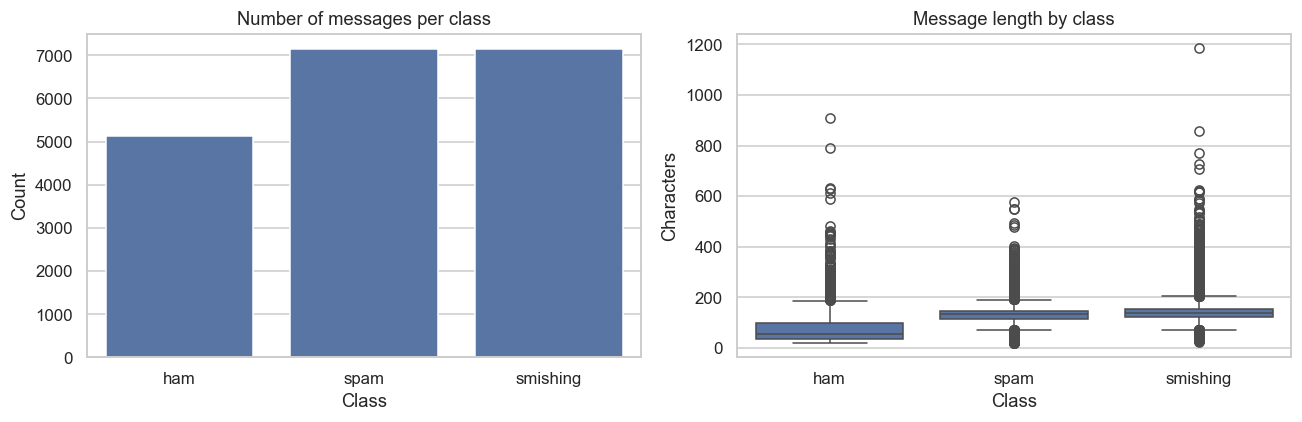

,message_length,word_count
LABEL,,
ham,55.0,11.0
smishing,138.0,23.0
spam,132.0,22.0


In [5]:
df['message_length'] = df['TEXT'].str.len()
df['word_count'] = df['TEXT'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='LABEL', order=['ham', 'spam', 'smishing'], ax=axes[0])
axes[0].set_title('Number of messages per class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='LABEL', y='message_length', order=['ham', 'spam', 'smishing'], ax=axes[1])
axes[1].set_title('Message length by class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()

df.groupby('LABEL')[['message_length', 'word_count']].median().round(1)

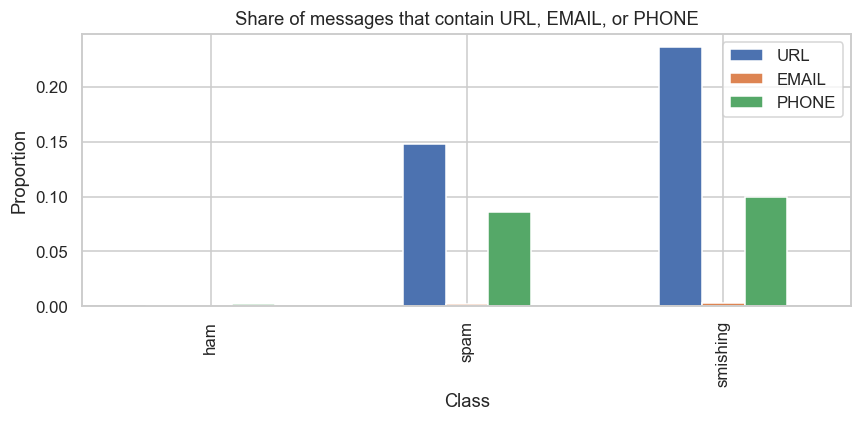

,URL,EMAIL,PHONE
LABEL,,,
ham,0.001,0.000,0.002
spam,0.148,0.002,0.086
smishing,0.237,0.003,0.100


In [6]:
flag_summary = (
    df.assign(
        URL=(df['URL'] == 'Yes').astype(int),
        EMAIL=(df['EMAIL'] == 'Yes').astype(int),
        PHONE=(df['PHONE'] == 'Yes').astype(int),
    )
    .groupby('LABEL')[['URL', 'EMAIL', 'PHONE']]
    .mean()
    .loc[['ham', 'spam', 'smishing']]
)

ax = flag_summary.plot(kind='bar', figsize=(8, 4))
ax.set_title('Share of messages that contain URL, EMAIL, or PHONE')
ax.set_xlabel('Class')
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()

flag_summary.round(3)

### Findings from the exploratory analysis

From the class count table, the dataset is close to balanced: about **7,142 spam**, **7,142 smishing**, and **5,133 ham** messages (around **19,417** in total). All of the available ham and spam are kept, and only smishing was capped to the spam count so it does not dominate. Because the classes are roughly even, macro F1 is a fair metric and the models are not strongly biased toward one label.

From the message length and word count plots, we can see a clear difference between ham and the two malicious classes. Ham messages tend to be much shorter, with a median length around **55 characters** and **11 words**. In contrast, both spam and smishing are longer, with median lengths close to **132 to 138 characters** and median word counts around **22 to 23 words**.

The URL, email, and phone indicators show that **URLs are the strongest structural signal**. Ham messages almost never contain any of these elements (URL, phone, and email are all near 0%). Smishing has the highest URL rate at about **23.7%**, followed by spam at **14.8%**. Phone numbers are present but much less frequent than in the previous synthetic dataset (around **10.0%** of smishing and **8.6%** of spam), and email addresses are rare in every class. This matches the idea that many of these real-world malicious messages push the user to open a link.

Overall, the EDA suggests that ham is easier to separate, while the harder decision will probably be distinguishing **spam** from **smishing**, since both classes share suspicious language, longer message formats, and similar structural indicators.

## 5. Text preprocessing

The model cannot use raw text directly, so we clean the messages first.

### Steps used here
- convert text to lowercase
- replace URLs with the token `__url__`
- replace emails with the token `__email__`
- replace phone numbers with the token `__phone__`
- remove repeated spaces

This makes the text more consistent while keeping useful patterns for classification.


In [7]:
URL_RE = re.compile(r'(https?://\S+|www\.\S+)')
EMAIL_RE = re.compile(r'\b[\w.+-]+@[\w-]+\.[\w.-]+\b')
PHONE_RE = re.compile(r'(\+?\d[\d\-\s().]{6,}\d)')


def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(' __url__ ', text)
    text = EMAIL_RE.sub(' __email__ ', text)
    text = PHONE_RE.sub(' __phone__ ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['TEXT'].apply(clean_text)

df[['TEXT', 'clean_text']].head(5)

,TEXT,clean_text
0,Don't necessarily expect it to be done before ...,don't necessarily expect it to be done before ...
1,dear surinder singh sokhi chinos are central ...,dear surinder singh sokhi chinos are central t...
2,"our mobile number has won å£5000, to claim cal...","our mobile number has won å£5000, to claim cal..."
3,Thanks for your Spam SMS report The ACMA will ...,thanks for your spam sms report the acma will ...
4,calling all night shoppers get rs off cash...,calling all night shoppers get rs off cashback...


## 6. Label encoding and numeric features

Scikit-learn models work with numeric labels, so the classes are converted from text into integers.

We also add a few simple numeric features from each message:
- message length
- word count
- digit count
- exclamation count

These features are simple, easy to explain, and can help separate normal messages from suspicious ones, based on the pattern and the structure some of this messages follow


In [8]:
from sklearn.preprocessing import LabelEncoder


def numeric_features(text):
    text = str(text)
    return pd.Series({
        'digit_count': sum(char.isdigit() for char in text),
        'exclamation_count': text.count('!'),
    })


extra_features = df['TEXT'].apply(numeric_features)
df = pd.concat([df, extra_features], axis=1)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['LABEL'])
LABEL_NAMES = list(label_encoder.classes_)

NUMERIC_COLS = ['message_length', 'word_count', 'digit_count', 'exclamation_count']
FEATURE_COLS = ['clean_text'] + NUMERIC_COLS

print('Label mapping:', dict(zip(LABEL_NAMES, range(len(LABEL_NAMES)))))
df[FEATURE_COLS + ['LABEL', 'label']].head()

Label mapping: {'ham': 0, 'smishing': 1, 'spam': 2}


,clean_text,message_length,word_count,digit_count,exclamation_count,LABEL,label
0,don't necessarily expect it to be done before ...,97,18,0,0,ham,0
1,dear surinder singh sokhi chinos are central t...,240,45,0,0,spam,2
2,"our mobile number has won å£5000, to claim cal...",100,19,15,0,spam,2
3,thanks for your spam sms report the acma will ...,152,22,0,0,smishing,1
4,calling all night shoppers get rs off cashback...,127,19,0,0,spam,2


## 7. Train/test split

We separate the dataset into training and testing sets.

`stratify=y` means both splits keep the same class proportion as the original dataset. That is important for a fair evaluation.

In [9]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])
print('Training class counts:', np.bincount(y_train))
print('Testing class counts:', np.bincount(y_test))

Training samples: 15533
Testing samples: 3884
Training class counts: [4106 5713 5714]
Testing class counts: [1027 1429 1428]


## 8. Build the preprocessing pipeline

This is the main scikit-learn block we will use.

### `TfidfVectorizer`
This converts text into numeric vectors. Each message is represented by the words it contains, and TF-IDF gives more importance to words that are informative for classification.

### `ColumnTransformer`
This lets us apply different preprocessing steps to different columns:
- TF-IDF to the text column
- scaling to the numeric columns

After that, it combines everything into a single feature matrix.

### `Pipeline`
A pipeline joins preprocessing and the classifier in one object. This makes the training and prediction process cleaner, because the same steps are applied every time.


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                'text_tfidf',
                TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2),
                'clean_text',
            ),
            (
                'numeric_data',
                MaxAbsScaler(),
                NUMERIC_COLS,
            ),
        ]
    )


models = {
    'Complement Naive Bayes': ComplementNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Linear SVM': LinearSVC(random_state=SEED),
}

## 9. Train the models

Here we train the three models and compare them with two metrics:
- **accuracy**: the proportion of correct predictions
- **macro F1**: the average F1 score across the three classes

Since the classes are close to balanced, macro F1 is a useful metric for comparing performance across all classes.

In [11]:
predictions = {}
fitted_models = {}
results = []

for model_name, classifier in models.items():
    model = Pipeline(
        steps=[
            ('preprocessor', build_preprocessor()),
            ('classifier', classifier),
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    fitted_models[model_name] = model
    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
results_df.round(4)

,model,accuracy,macro_f1
0,Linear SVM,0.8862,0.8915
1,Logistic Regression,0.8834,0.8891
2,Complement Naive Bayes,0.8043,0.8123


## 10. Detailed evaluation

After training, we look at the results in more detail using:
- a classification report
- a confusion matrix

The confusion matrix is useful because it shows which classes are being confused with each other.


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

for model_name, y_pred in predictions.items():
    print('=' * 70)
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4))

Complement Naive Bayes
              precision    recall  f1-score   support

         ham     0.8720    0.9416    0.9054      1027
    smishing     0.7793    0.7782    0.7787      1429
        spam     0.7752    0.7318    0.7529      1428

    accuracy                         0.8043      3884
   macro avg     0.8088    0.8172    0.8123      3884
weighted avg     0.8023    0.8043    0.8027      3884

Logistic Regression
              precision    recall  f1-score   support

         ham     0.9340    0.9640    0.9487      1027
    smishing     0.8966    0.8251    0.8593      1429
        spam     0.8363    0.8838    0.8594      1428

    accuracy                         0.8834      3884
   macro avg     0.8890    0.8909    0.8891      3884
weighted avg     0.8843    0.8834    0.8830      3884

Linear SVM
              precision    recall  f1-score   support

         ham     0.9318    0.9581    0.9448      1027
    smishing     0.8983    0.8404    0.8684      1429
        spam     0.84

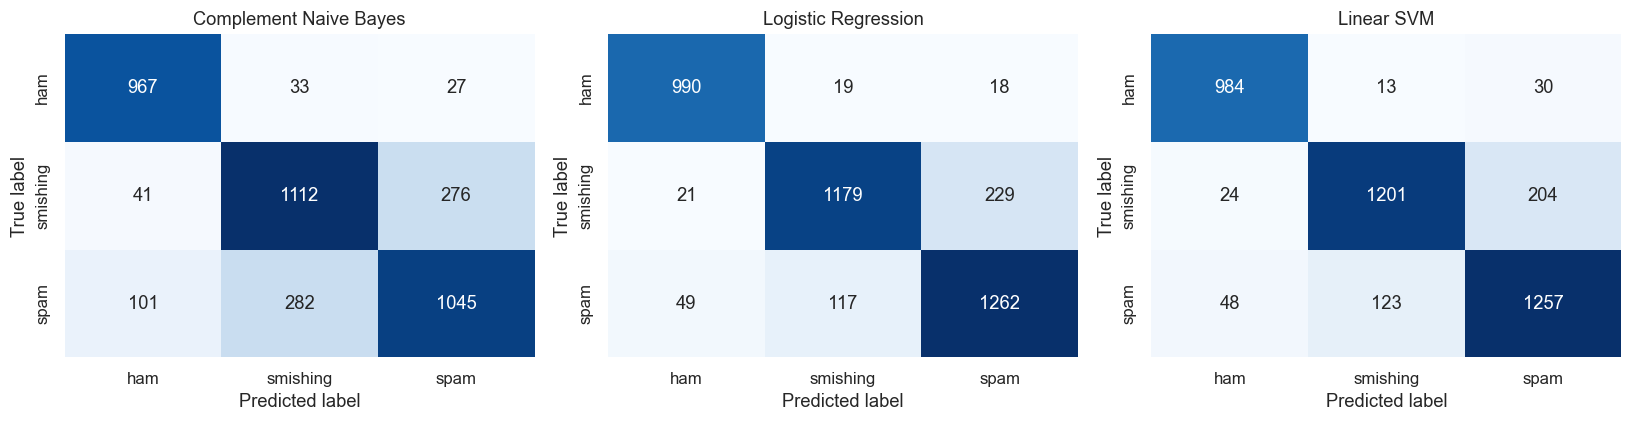

In [13]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))

if len(predictions) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()

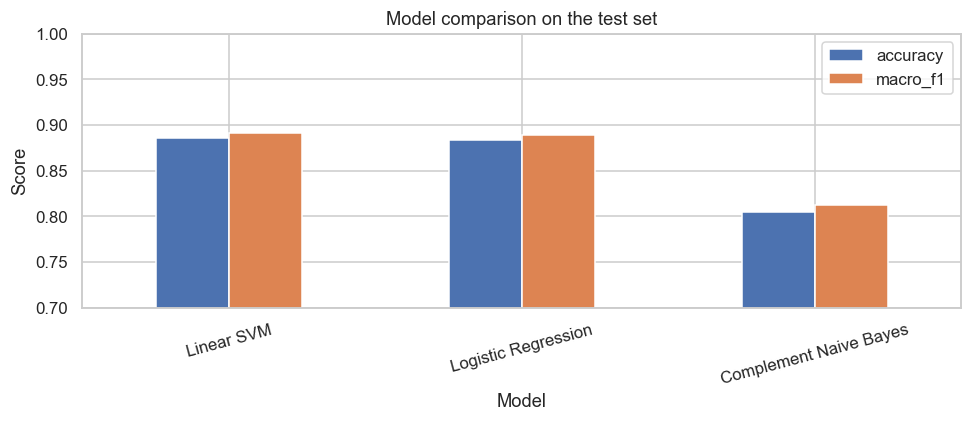

Best model: Linear SVM


In [14]:
ax = results_df.plot(kind='bar', x='model', y=['accuracy', 'macro_f1'], figsize=(9, 4))
ax.set_title('Model comparison on the test set')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0.70, 1.00)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['model']
print('Best model:', best_model_name)

### Findings from the model comparison

The comparison table shows that the two linear models perform best and are almost tied: **Linear SVM** reaches a macro F1 of about **0.892** (accuracy **0.886**), with **Logistic Regression** right behind at macro F1 close to **0.889**. **Complement Naive Bayes** is clearly lower, around **0.812**.

This tells us that the text patterns in the dataset can still be captured well with standard TF-IDF features. The scores are lower than on the previous synthetic dataset, which is expected: this consolidated dataset is larger and built from three different real-world sources, so the messages are more varied and harder to separate.

From the classification reports and confusion matrices, we can also see that **ham** is the easiest class to classify (F1 around 0.94). The remaining mistakes are mostly between **spam** and **smishing** (each around F1 0.86), which makes sense because both types of messages can include offers, urgent language, links, phone numbers, or requests for action.

A practical conclusion from this section is that **Linear SVM** is the best option for this notebook because it combines the highest scores with a workflow that is still easy to explain.

## 11. Try the best model with new example messages

This section tests the best model with a larger set of example messages that were not taken from the dataset.


In [15]:
def build_feature_frame(messages):
    new_df = pd.DataFrame({'TEXT': messages})
    new_df['clean_text'] = new_df['TEXT'].apply(clean_text)
    new_df['message_length'] = new_df['TEXT'].str.len()
    new_df['word_count'] = new_df['TEXT'].str.split().apply(len)
    extra = new_df['TEXT'].apply(numeric_features)
    new_df = pd.concat([new_df, extra], axis=1)
    return new_df[FEATURE_COLS]


example_messages = [
    "Hey, are we still meeting at 7 pm after class?",  # ham
    "Can you send me the notes from today's lecture when you have time?",  # ham
    "I am outside the library, let us know when you arrive.",  # ham
    "Congratulations! You won a free vacation. Call now to claim your prize!",  # smishing
    "Limited time offer! Get 50% off on all products. Visit https://fake-store.com now!",  # spam
    "You have been selected for an exclusive cashback reward. Reply YES now!",  # spam
    "Your bank account will be suspended today. Verify now at http://fake-link.com",  # smishing
    "Dear customer, your payment account has been locked. Call 8001234567 immediately to restore access.",  # smishing
    "Notice: your package delivery failed. Update your address here: http://track-package-now.com",  # smishing
    "Hey bro, are you coming to the party tonight? Did you purchased your ticket at https://ticket-portal.com ?",  # ham
]

labels = [
    "ham",
    "ham",
    "ham",
    "smishing",
    "spam",
    "spam",
    "smishing",
    "smishing",
    "smishing",
    "ham",
]

best_model = fitted_models[best_model_name]
example_features = build_feature_frame(example_messages)
example_predictions = best_model.predict(example_features)
example_labels = label_encoder.inverse_transform(example_predictions)

pd.DataFrame({
    'message': example_messages,
    'predicted_label': example_labels,
    'true_label': labels,
})


,message,predicted_label,true_label
0,"Hey, are we still meeting at 7 pm after class?",ham,ham
1,Can you send me the notes from today's lecture...,spam,ham
2,"I am outside the library, let us know when you...",ham,ham
3,Congratulations! You won a free vacation. Call...,smishing,smishing
4,Limited time offer! Get 50% off on all product...,spam,spam
5,You have been selected for an exclusive cashba...,smishing,spam
6,Your bank account will be suspended today. Ver...,smishing,smishing
7,"Dear customer, your payment account has been l...",smishing,smishing
8,Notice: your package delivery failed. Update y...,smishing,smishing
9,"Hey bro, are you coming to the party tonight? ...",ham,ham


### Notes on the example predictions

This section is useful because it shows how the trained model reacts to messages outside the dataset table. We included normal messages, promotional messages, and suspicious messages with links, prizes, account alerts, and payment requests.

These examples help us check whether the model behavior is consistent with the patterns seen during the exploratory analysis and the evaluation stage.


## 12. Conclusion

By working on this project, we found and learned the following:

- For this dataset, **Logistic Regression** and **Linear SVM** are strong and easy to explain choices.
- `TF-IDF vectorizer` does a good job on encoding words to numerical features, since it considers term frequency and document frequency
- The dataset is close to balanced and has a good amount of examples (about 19,417 messages from three real public sources), so the model comparison is fair across the three classes.
- Smishing messages stand out because they contain URLs more often than the other classes (around 23.7%, compared with 14.8% for spam and almost none for ham).
- Although we initially thought Naive Bayes algorithm would excel on performance since this model is mainly used for natural language prediction and classification, the best result in this notebook comes from Linear SVM, which performs better than the other two models on the test set.
- Most of the remaining classification errors happen between spam and smishing, not between ham and the malicious classes. After analyzing some data examples, spam and smishing messages tend to be more similar than ham messages, because of the message structure and length, but also because of which words are used, and the context and combination of the words.
- Future work on this would be to research on how can we distinguish and classify between two similar natural language content types, for example, between types of spam